In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


In [2]:
directory = '/mnt/users/darnej/MPhys/galaxies_dataframe.csv'

dataframe = pd.read_csv(directory)

dataframe.head()

,Unnamed: 0,Gal_number,r_half,r_half_index,z_half,z_half_index,ratio,mass,T_total_mass,gas_r_half,gas_r_half_index,gas_z_half,gas_z_half_index,gas_ratio,gas_mass,specific_angular_mom,h1_specific_angular_mom,max_R
0,0,1,2.796819,3071276.0,0.509727,3082734.0,0.182253,5.462038e+10,8.014141e+10,12.127141,4743.0,0.372715,4632.0,0.030734,1.596592e+10,"[np.float64(2.0727774928233594e-15), np.float6...","[unyt_quantity(7.44506508e-15, 'kpc/s'), unyt_...",52.820850
1,1,2,6.205739,4416553.0,0.832978,4465604.0,0.134227,7.992248e+10,1.374154e+11,20.650873,9618.0,0.397302,9413.0,0.019239,3.561092e+10,"[np.float64(2.173178341029385e-14), np.float64...","[unyt_quantity(7.68315701e-14, 'kpc/s'), unyt_...",55.253423
2,2,3,2.458984,11788695.0,1.139515,11818270.0,0.463409,2.380689e+11,3.171829e+11,3.813950,182.0,2.635289,459.0,0.690960,2.289530e+10,"[np.float64(3.0674512797265425e-15), np.float6...","[unyt_quantity(1.33284912e-13, 'kpc/s'), unyt_...",106.289677
3,3,4,2.430347,19912.0,0.750322,19902.0,0.308730,3.422925e+08,1.519439e+09,3.873377,260115.0,0.990988,283999.0,0.255846,8.816963e+08,"[np.float64(4.920547755956409e-16), np.float64...","[unyt_quantity(1.19530668e-15, 'kpc/s'), unyt_...",8.207984
4,4,5,4.987262,13399794.0,1.900220,13409656.0,0.381015,2.442997e+11,3.275695e+11,8.764368,802.0,2.254053,1638.0,0.257184,2.754446e+10,"[np.float64(2.4674449605541102e-14), np.float6...","[unyt_quantity(6.12358078e-14, 'kpc/s'), unyt_...",83.383848


In [3]:
masses = dataframe['mass'].to_numpy()
gas_r_half = dataframe['gas_r_half'].to_numpy()
ratio = dataframe['ratio'].to_numpy()
gas_masses = dataframe['gas_mass'].to_numpy()
t_total_mass = dataframe['T_total_mass'].to_numpy()

#masses = mass of gasses + 

mask = (ratio > 0.05) & (masses > 0)

masses = masses[mask]
gas_r_half = gas_r_half[mask]
ratio = ratio[mask]
gas_masses = gas_masses[mask]
t_total_mass = t_total_mass[mask]


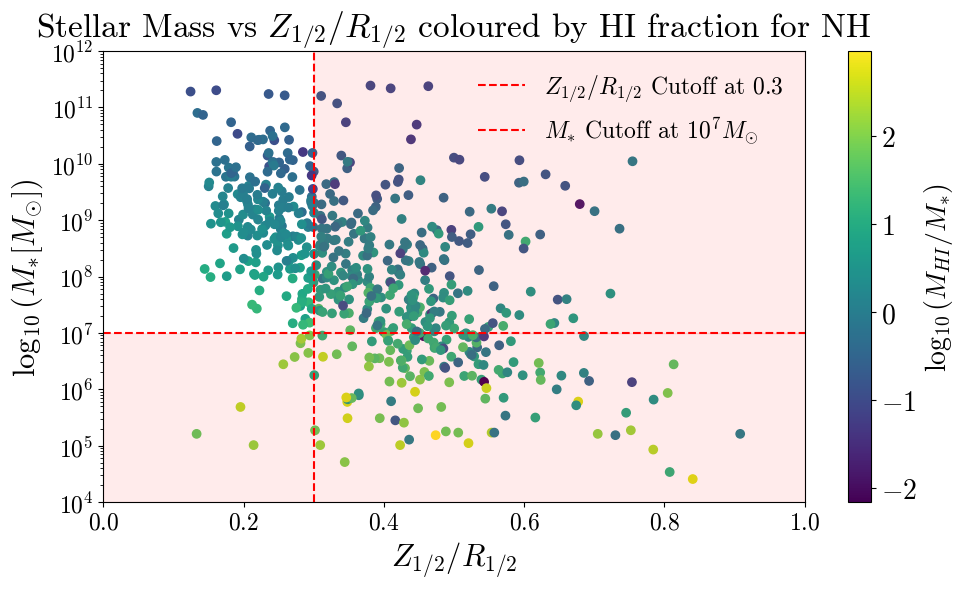

In [33]:
plt.rcParams["axes.formatter.use_mathtext"] = True
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams['font.family'] = 'cmr10'  # Computer Modern Roman
plt.rcParams["xtick.labelsize"] = 17   # Increase x-axis tick font size
plt.rcParams["ytick.labelsize"] = 17   # Increase y-axis tick font size

HI_fraction = gas_masses/masses

plt.figure(figsize=(10, 6))
sc = plt.scatter(ratio, masses, c = np.log10(HI_fraction), cmap='viridis')
#plt.xscale('log')
plt.yscale('log')

cbar = plt.colorbar(sc, label='HI Fraction')
cbar.set_label("$\log_{10}(M_{HI}/M_{*})$", fontsize=20)
cbar.ax.tick_params(labelsize=20)

plt.ylabel('$\log_{10}{(M_{*}[M_{\odot}])}$', size=22)
plt.xlabel('$Z_{1/2}/R_{1/2}$', size=22)
plt.title('Stellar Mass vs $Z_{1/2}/R_{1/2}$ coloured by HI fraction for NH', size=24)

plt.axvline(x = 0.3, color = 'r', linestyle = '--', label='$Z_{1/2}/R_{1/2}$ Cutoff at 0.3')
plt.axhline(y = 10**7, color = 'r', linestyle = '--', label='$M_{*}$ Cutoff at $10^{7} M_{\odot}$')

plt.axhspan(10**4, 10**7, color='red', alpha=0.08)
plt.fill_between(x=[0.3,1], y1=10**7, y2=10**12, color='red', alpha=0.08)

plt.xlim(0,1)
plt.ylim(10**4, 10**12)

plt.legend(prop ={'size': 17}, frameon = False, loc = 'upper right')
plt.tight_layout()
plt.show()